In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *

from matplotlib.cm import ScalarMappable
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
'''GRa (Mera)
a30: humidity_magic = 5
a31: a30 + cloud_magic = 0
a32: a31 + cnos x10
a33: a31 + cnos x100
a34: a31 + cnos /10
a35: a31 + cnos /100
a36 :  + corr humidité +5%
a37 : + corr humidité -5%

GRf (Fedchenko)
f30: humidity_magic = 5
f31: f30 + cloud_magic = 0
f32: f31 + cnos x10
f33: f31 + cnos x100
f34: f31 + cnos /10
f35: f31 + cnos /100
f36 :  + corr humidité +5%
f37 : + corr humidité -5%
'''

'GRa (Mera)\na30: humidity_magic = 5\na31: a30 + cloud_magic = 0\na32: a31 + cnos x10\na33: a31 + cnos x100\na34: a31 + cnos /10\na35: a31 + cnos /100\na36 :  + corr humidité +5%\na37 : + corr humidité -5%\n\nGRf (Fedchenko)\nf30: humidity_magic = 5\nf31: f30 + cloud_magic = 0\nf32: f31 + cnos x10\nf33: f31 + cnos x100\nf34: f31 + cnos /10\nf35: f31 + cnos /100\nf36 :  + corr humidité +5%\nf37 : + corr humidité -5%\n'

In [3]:
iyr = '01-01-2016'
fyr = '31-12-2016'
domain = 'GRf'
domain_2 = 'MARFed'
d='f'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain_2)  
print(latS,latN,lonW,lonE)
variable='tmp'
var='tmp'
units='°C'
nx=15;ny=15

36 42 66 78


In [4]:
sourceData='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/'+domain+'/sensitivity_tests/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain +'/'

In [5]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc' 
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
dsF_lon=ds_grF.LON[nx:-nx,ny:-ny]
dsF_lat=ds_grF.LAT[nx:-nx,ny:-ny]
dsF_SH=ds_grF.SH[nx:-nx,ny:-ny]

lat_min=dsF_lat.values.min()
lat_max=dsF_lat.values.max()

lon_min=dsF_lon.values.min()
lon_max=dsF_lon.values.max()

orog_mar = xr.open_dataset(sourceDataGrid+fileName_grF).SH.load()

orog_mar = orog_mar[nx:-nx,ny:-ny]
orog_mar = orog_mar.rename({'x': 'X', 'y':'Y'})

In [6]:
elev_flat = dsF_SH.values.flatten()
###Bin elevation (interval 250 m)
elev_bins = np.arange(0, np.max(elev_flat) + 250, 250)
elev_bin_labels = (elev_bins[:-1] + elev_bins[1:]) / 2

In [7]:
ds_TTZ_s2=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/MARout/'+domain+'/spin2/work/daily/'
                          +'TTZ_daymean_MARv3.14_ER5_spin2_'+domain+'_2016.nc')['TTZ'].isel(ZTQLEV=0)[:,ny:-ny,nx:-nx]
# ##
ds_TTZ_30=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'30.nc')['TTZ'].isel(ZTQLEV=0)[:,ny:-ny,nx:-nx]
ds_TTZ_31=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'31.nc')['TTZ'].isel(ZTQLEV=0)[:,ny:-ny,nx:-nx]
ds_TTZ_32=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'32.nc')['TTZ'].isel(ZTQLEV=0)[:,ny:-ny,nx:-nx]
ds_TTZ_33=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'33.nc')['TTZ'].isel(ZTQLEV=0)[:,ny:-ny,nx:-nx]
ds_TTZ_34=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'34.nc')['TTZ'].isel(ZTQLEV=0)[:,ny:-ny,nx:-nx]
ds_TTZ_35=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'35.nc')['TTZ'].isel(ZTQLEV=0)[:,ny:-ny,nx:-nx]
ds_TTZ_36=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'36.nc')['TTZ'].isel(ZTQLEV=0)[:,ny:-ny,nx:-nx]
ds_TTZ_37=xr.open_dataset(sourceData+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016.'+d+'37.nc')['TTZ'].isel(ZTQLEV=0)[:,ny:-ny,nx:-nx]

In [8]:
##seasons
ds_TTZ_s2_per=ds_TTZ_s2.groupby('TIME.season').mean('TIME')

ds_TTZ_30_per=ds_TTZ_30.groupby('TIME.season').mean('TIME')
ds_TTZ_31_per=ds_TTZ_31.groupby('TIME.season').mean('TIME')
ds_TTZ_32_per=ds_TTZ_32.groupby('TIME.season').mean('TIME')
ds_TTZ_33_per=ds_TTZ_33.groupby('TIME.season').mean('TIME')
ds_TTZ_34_per=ds_TTZ_34.groupby('TIME.season').mean('TIME')
ds_TTZ_35_per=ds_TTZ_35.groupby('TIME.season').mean('TIME')
ds_TTZ_36_per=ds_TTZ_36.groupby('TIME.season').mean('TIME')
ds_TTZ_37_per=ds_TTZ_37.groupby('TIME.season').mean('TIME')

In [9]:
model3='era5-land'
ds_obs= xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/fainx/'+model3+'/era5_land_'+domain +'_t2m.nc')['t2m'] -273.15
ds_obs=ds_obs.rename({'valid_time':'TIME','longitude' :'lon','latitude' :'lat'})
ds_obs = ds_obs.sel(TIME=slice(iyr, fyr))
ds_obs = ds_obs.where((ds_obs.lat >= lat_min) & (ds_obs.lat <= lat_max), drop=True)
ds_obs = ds_obs.where((ds_obs.lon >= lon_min) & (ds_obs.lon <= lon_max), drop=True)

ds_obs_day = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/fainx/'+model3+'/2016/t2m.day_era5-land_2016.nc')['t2m'] -273.15
# ds_obs_day_high = ds_obs_day.where(orog_mar > alti_thrs)
# ds_obs_day_low = ds_obs_day.where(orog_mar < alti_thrs)

field_obs=dom.field_dom(ds_obs,domain_2)

field_obs_day=dom.field_dom(ds_obs_day,domain_2)
field_obs_day= field_obs_day.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'TIME'})

# field_obs_day_high=dom.field_dom(ds_obs_day_high,domain_2)
# field_obs_day_high= field_obs_day_high.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})

# field_obs_day_low=dom.field_dom(ds_obs_day_low,domain_2)
# field_obs_day_low= field_obs_day_low.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})

ds_obs_per=field_obs.groupby('TIME.season').mean('TIME')

In [10]:
modelList=['ERA5-Land','spin2','30','31','32','33','34','35','36','37']

## MAM

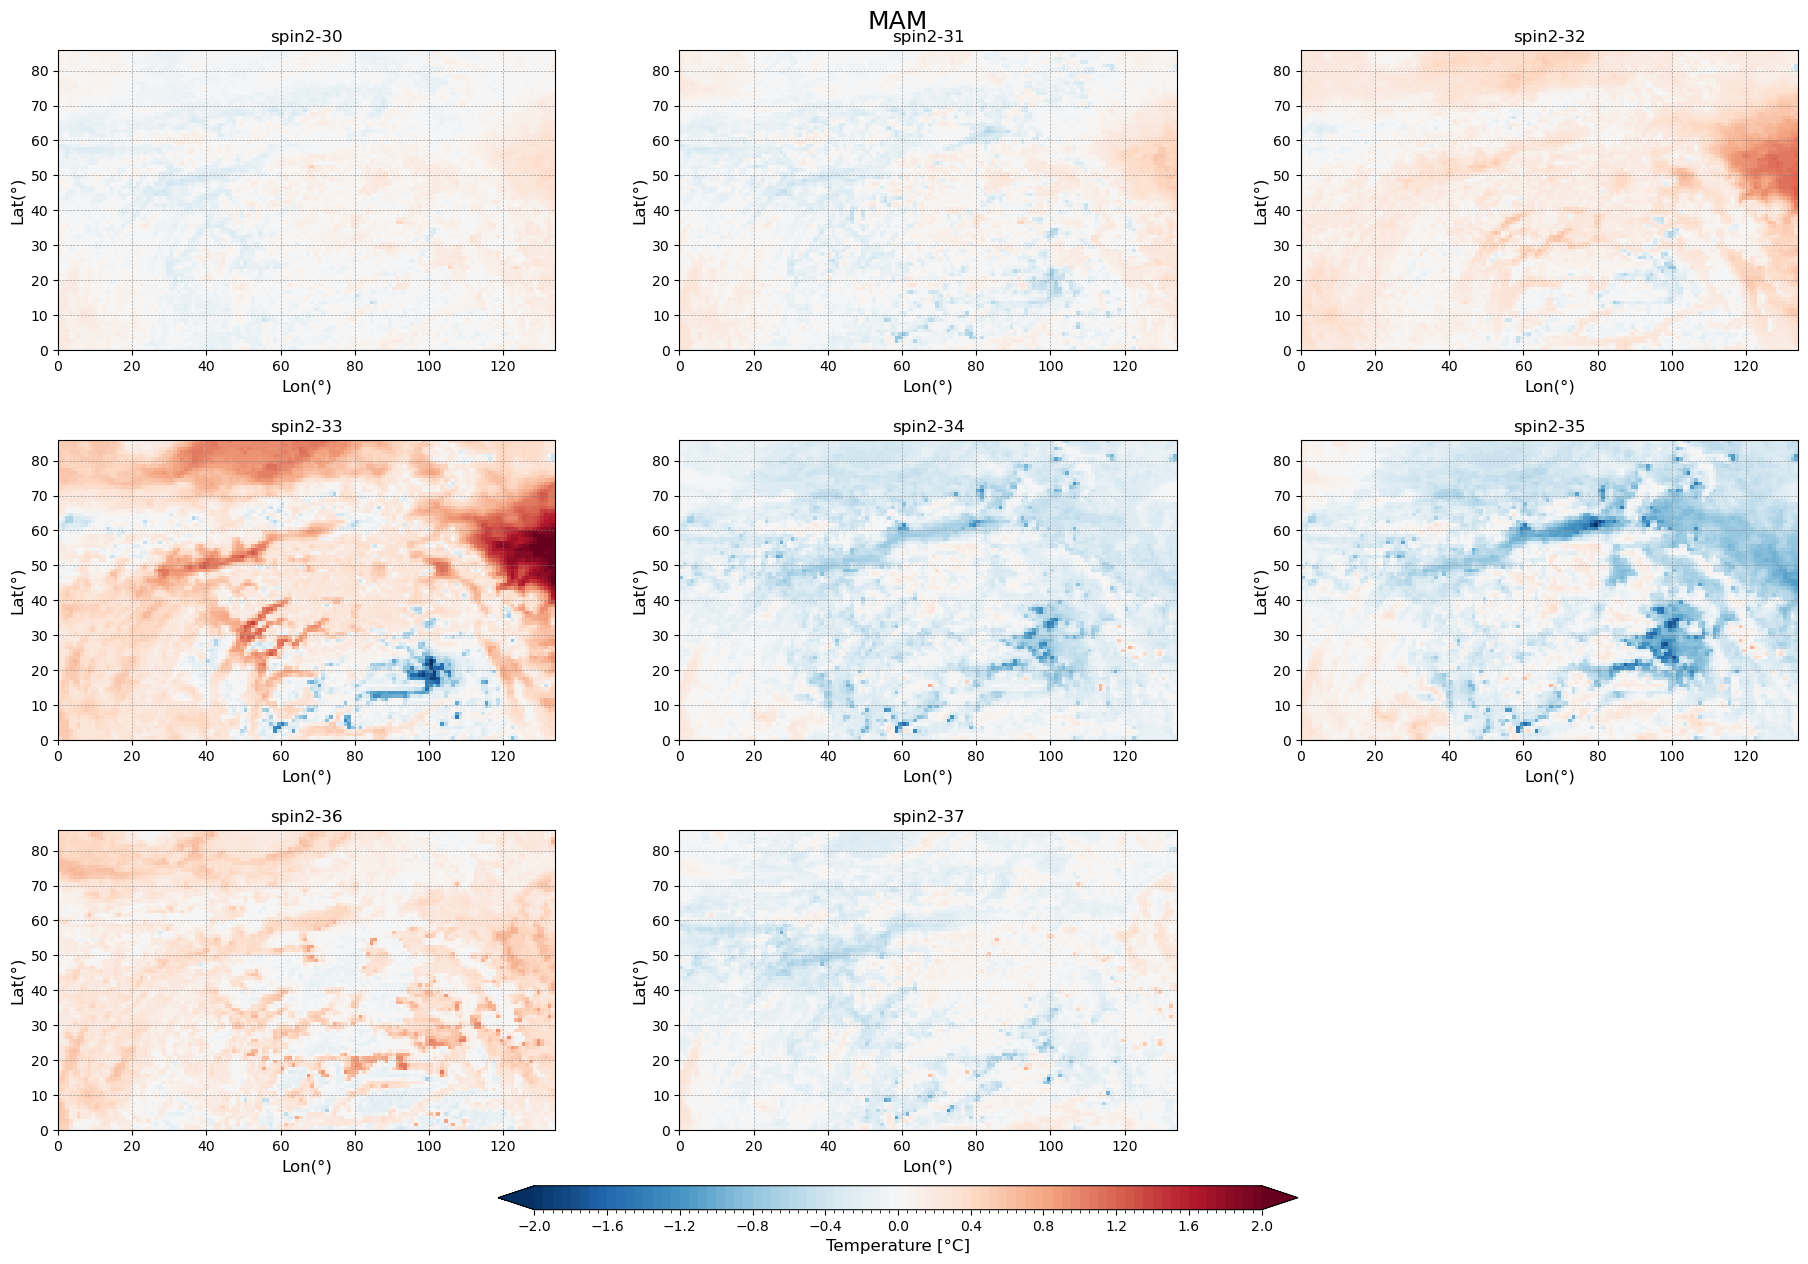

In [11]:
season='MAM'
# plotList=[ds_obs_per.sel(season=season),
#           ds_TTZ_s2_per.sel(season=season),
#           ds_TTZ_30_per.sel(season=season),
#           ds_TTZ_31_per.sel(season=season),
#           ds_TTZ_32_per.sel(season=season),
#           ds_TTZ_33_per.sel(season=season),
#           ds_TTZ_34_per.sel(season=season),
#           ds_TTZ_35_per.sel(season=season)]

plotList=[ds_TTZ_s2_per.sel(season=season)-ds_TTZ_30_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_31_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_32_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_33_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_34_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_35_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_36_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_37_per.sel(season=season)]


##
clevs=np.arange(-2,2.05,0.05);
ticks=np.arange(-2,2.1,0.4);
cmap = plt.get_cmap("RdBu_r")
norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=3
ncols=3

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

i=0
# CS1= axs[i].pcolormesh(ds_obs_per.lon, ds_obs_per.lat, ds_obs_per.sel(season=season), cmap=cmap,  norm=norm)
# axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
# axs[i].set_xlabel('Lon(°)', fontsize=12)
# axs[i].set_ylabel('Lat(°)', fontsize=12)
# axs[i].set_title(modelList[i] )

                       
for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title('spin2-'+ modelList[i+2] )

title =season
fig.suptitle(title,y=0.9, fontsize = 18)

fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
axs[8].remove()   


# # --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=ticks, spacing='proportional')
cbar.set_label('Temperature [°C]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)

plt.savefig(folder_figure+'MAR_sensitivity_tests_spatial_deviation_from_spin2'+season+'_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()

## JJA

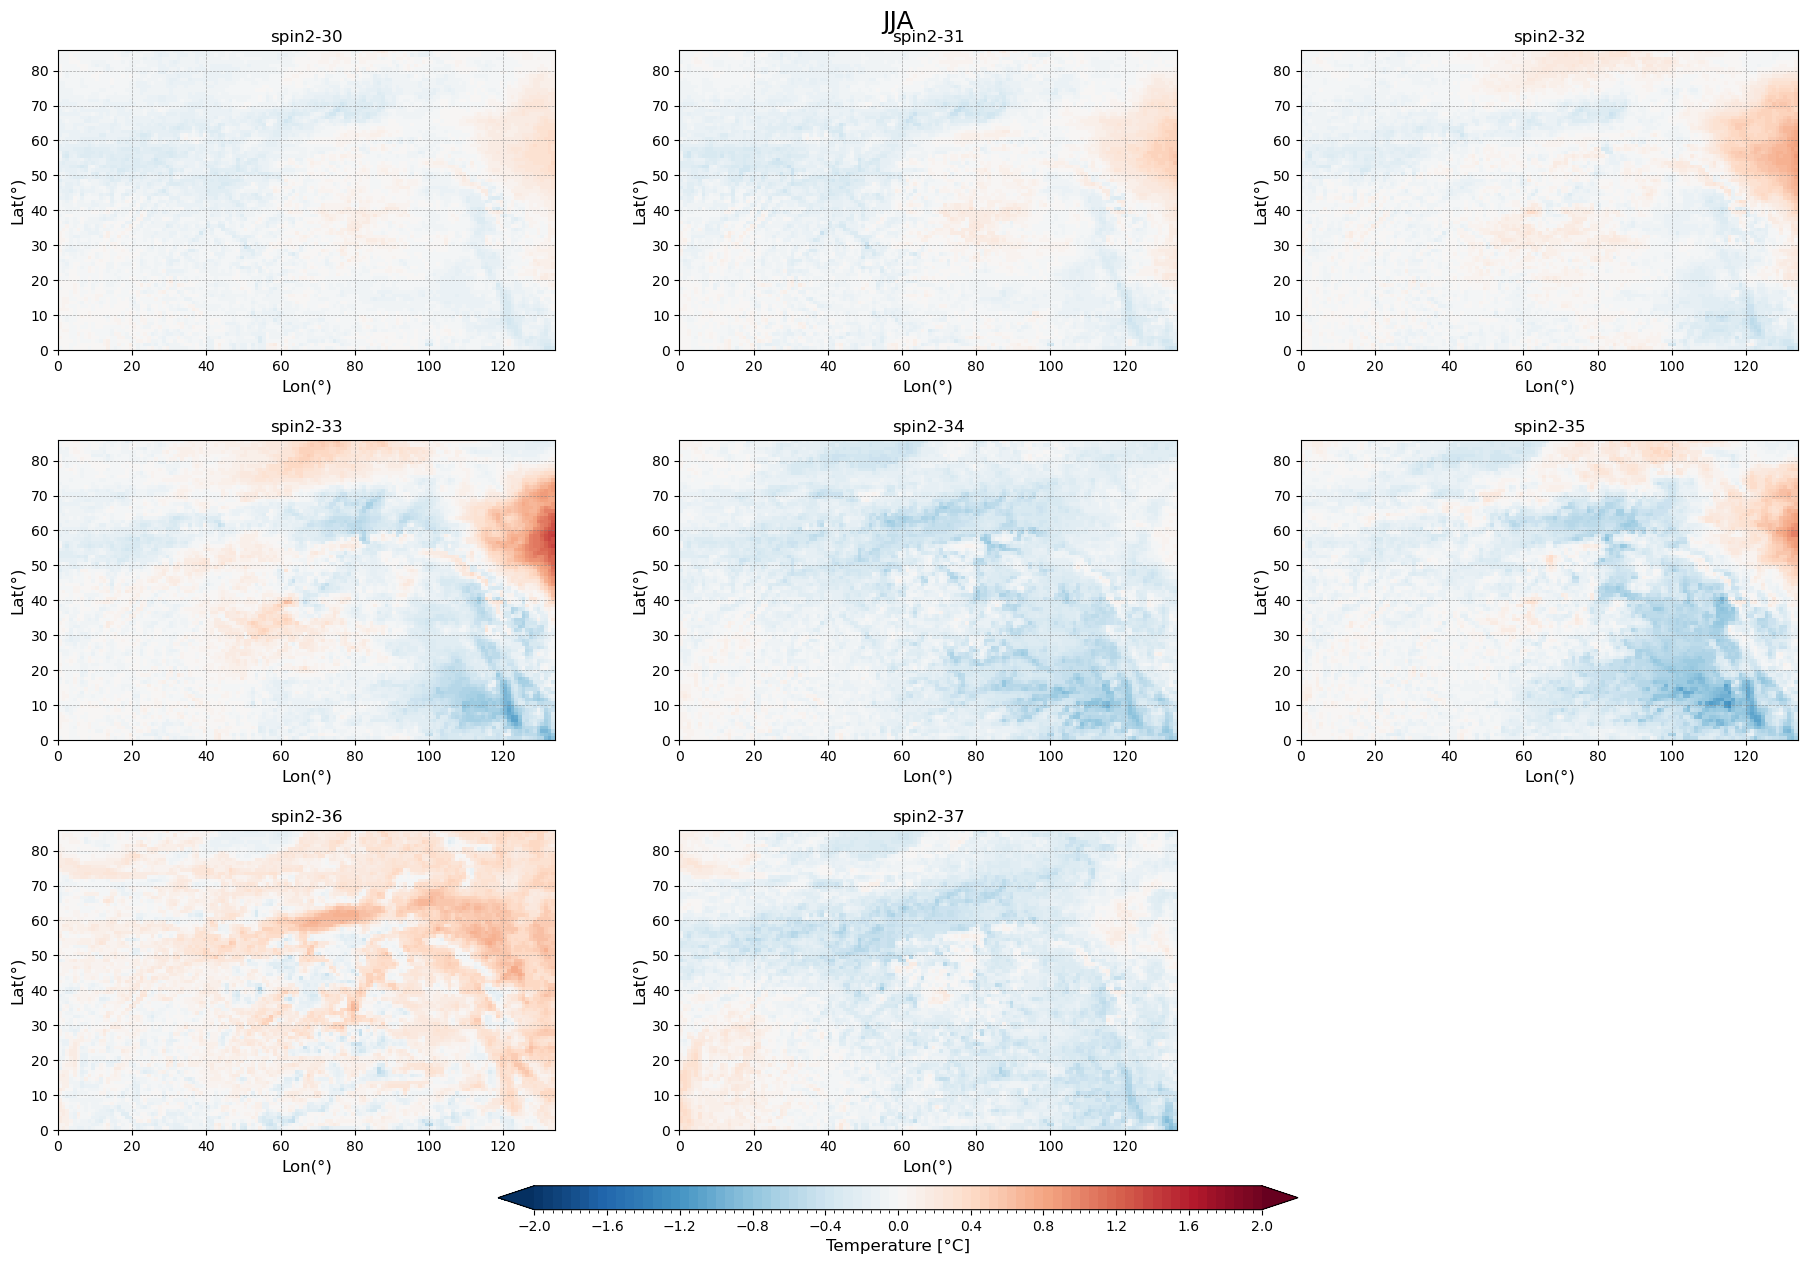

In [12]:
season='JJA'
# plotList=[ds_obs_per.sel(season=season),
#           ds_TTZ_s2_per.sel(season=season),
#           ds_TTZ_30_per.sel(season=season),
#           ds_TTZ_31_per.sel(season=season),
#           ds_TTZ_32_per.sel(season=season),
#           ds_TTZ_33_per.sel(season=season),
#           ds_TTZ_34_per.sel(season=season),
#           ds_TTZ_35_per.sel(season=season)]

plotList=[ds_TTZ_s2_per.sel(season=season)-ds_TTZ_30_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_31_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_32_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_33_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_34_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_35_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_36_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_37_per.sel(season=season)]

##
clevs=np.arange(-2,2.05,0.05);
ticks=np.arange(-2,2.1,0.4);
cmap = plt.get_cmap("RdBu_r")
norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=3
ncols=3

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

i=0
# CS1= axs[i].pcolormesh(ds_obs_per.lon, ds_obs_per.lat, ds_obs_per.sel(season=season), cmap=cmap,  norm=norm)
# axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
# axs[i].set_xlabel('Lon(°)', fontsize=12)
# axs[i].set_ylabel('Lat(°)', fontsize=12)
# axs[i].set_title(modelList[i] )

                       
for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title('spin2-'+ modelList[i+2] )

title =season
fig.suptitle(title,y=0.9, fontsize = 18)

fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
axs[8].remove()   


# # --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=ticks, spacing='proportional')
cbar.set_label('Temperature [°C]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
plt.savefig(folder_figure+'MAR_sensitivity_tests_spatial_deviation_from_spin2'+season+'_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()

## SON

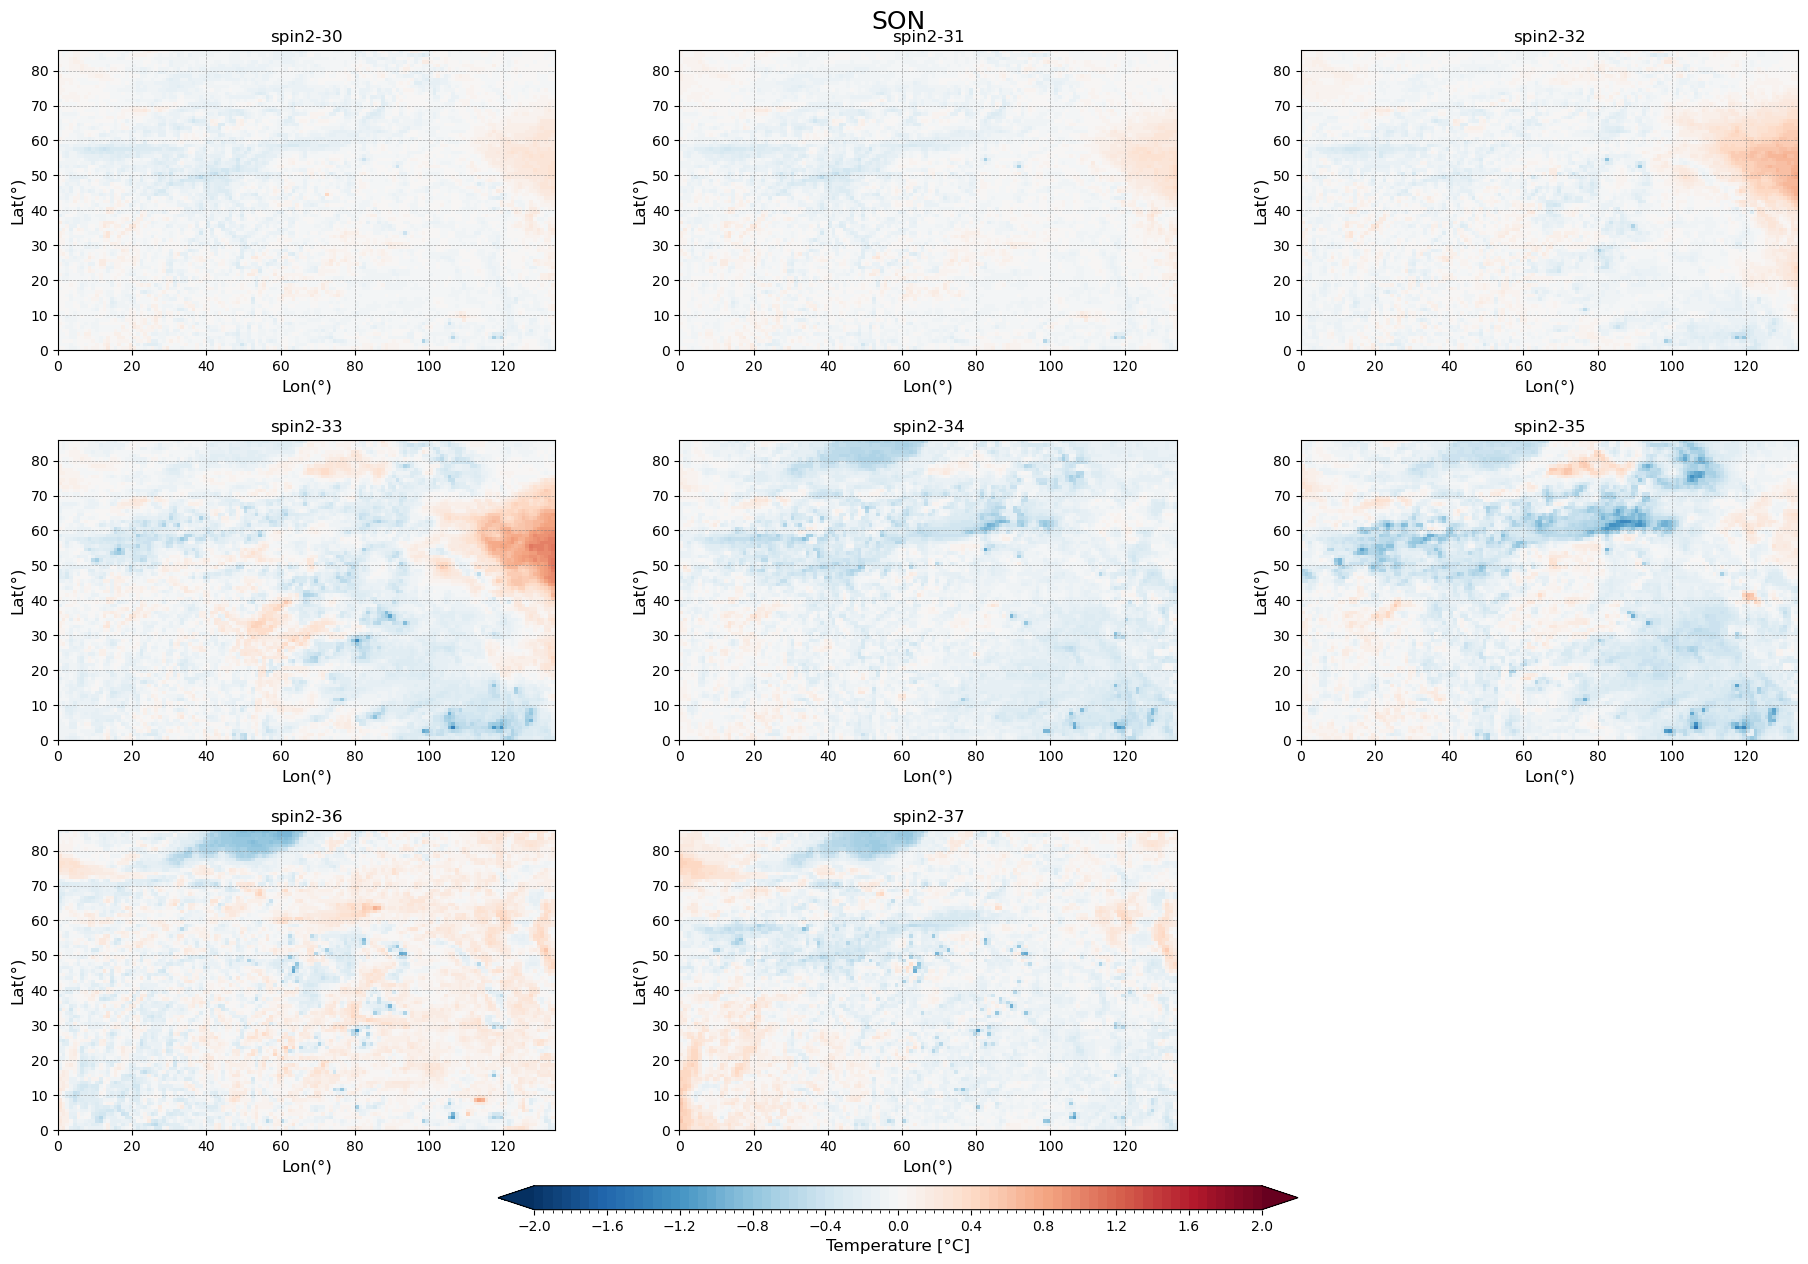

In [13]:
season='SON'
# plotList=[ds_obs_per.sel(season=season),
#           ds_TTZ_s2_per.sel(season=season),
#           ds_TTZ_30_per.sel(season=season),
#           ds_TTZ_31_per.sel(season=season),
#           ds_TTZ_32_per.sel(season=season),
#           ds_TTZ_33_per.sel(season=season),
#           ds_TTZ_34_per.sel(season=season),
#           ds_TTZ_35_per.sel(season=season)]

plotList=[ds_TTZ_s2_per.sel(season=season)-ds_TTZ_30_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_31_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_32_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_33_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_34_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_35_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_36_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_37_per.sel(season=season)]

##
clevs=np.arange(-2,2.05,0.05);
ticks=np.arange(-2,2.1,0.4);
cmap = plt.get_cmap("RdBu_r")
norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=3
ncols=3

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

i=0
# CS1= axs[i].pcolormesh(ds_obs_per.lon, ds_obs_per.lat, ds_obs_per.sel(season=season), cmap=cmap,  norm=norm)
# axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
# axs[i].set_xlabel('Lon(°)', fontsize=12)
# axs[i].set_ylabel('Lat(°)', fontsize=12)
# axs[i].set_title(modelList[i] )
                       
for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title('spin2-'+ modelList[i+2] )

title =season
fig.suptitle(title,y=0.9, fontsize = 18)

fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
axs[8].remove()   


# # --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=ticks, spacing='proportional')
cbar.set_label('Temperature [°C]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
plt.savefig(folder_figure+'MAR_sensitivity_tests_spatial_deviation_from_spin2'+season+'_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()

# DJF

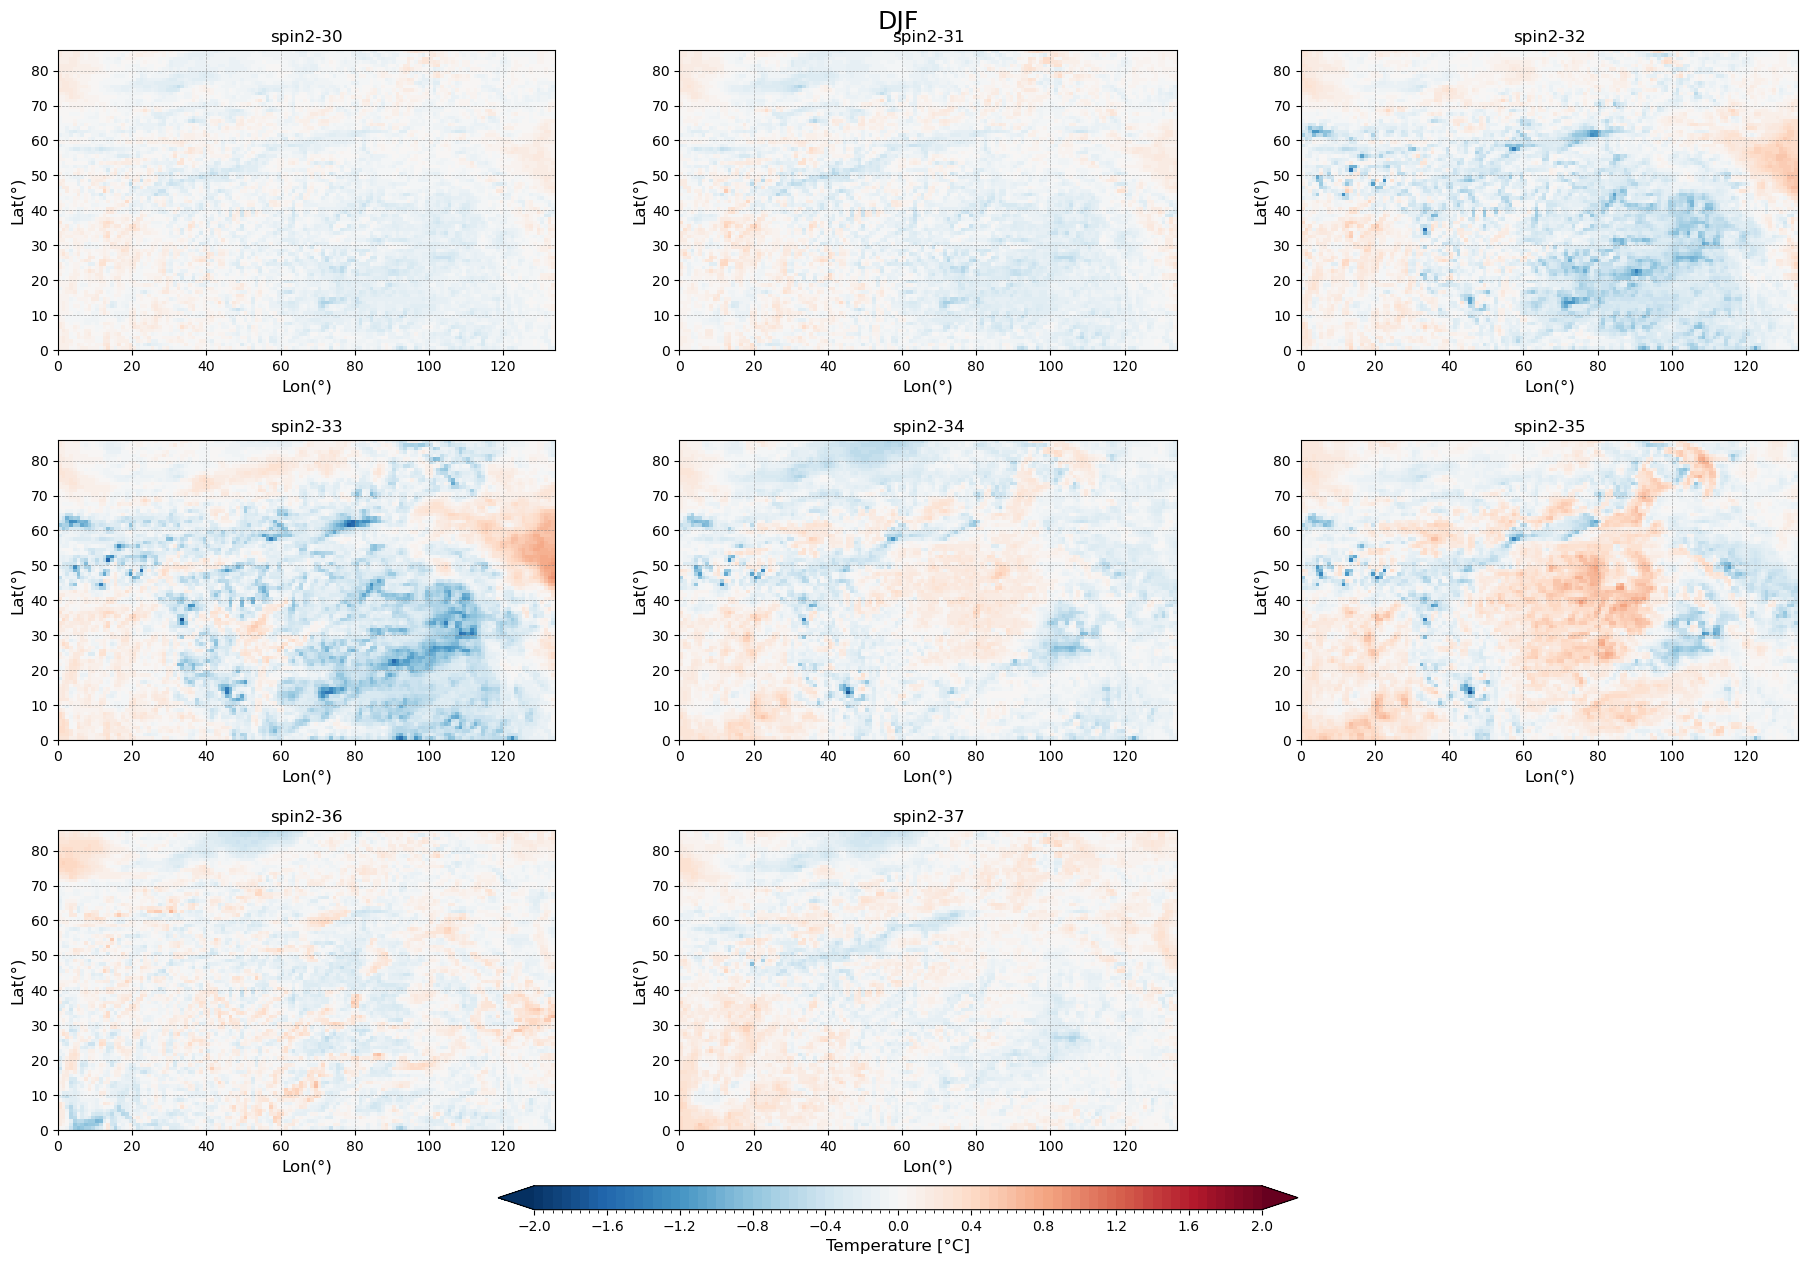

In [14]:
season='DJF'
# plotList=[ds_obs_per.sel(season=season),
#           ds_TTZ_s2_per.sel(season=season),
#           ds_TTZ_30_per.sel(season=season),
#           ds_TTZ_31_per.sel(season=season),
#           ds_TTZ_32_per.sel(season=season),
#           ds_TTZ_33_per.sel(season=season),
#           ds_TTZ_34_per.sel(season=season),
#           ds_TTZ_35_per.sel(season=season)]

plotList=[ds_TTZ_s2_per.sel(season=season)-ds_TTZ_30_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_31_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_32_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_33_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_34_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_35_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_36_per.sel(season=season),
          ds_TTZ_s2_per.sel(season=season)-ds_TTZ_37_per.sel(season=season)]
##
clevs=np.arange(-2,2.05,0.05);
ticks=np.arange(-2,2.1,0.4);
cmap = plt.get_cmap("RdBu_r")
norm = plt.Normalize(vmin=clevs.min(), vmax=clevs.max())
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N, extend='both')
nrows=3
ncols=3

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(20,20))
axs=axs.flatten()

i=0
# CS1= axs[i].pcolormesh(ds_obs_per.lon, ds_obs_per.lat, ds_obs_per.sel(season=season), cmap=cmap,  norm=norm)
# axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
# axs[i].set_xlabel('Lon(°)', fontsize=12)
# axs[i].set_ylabel('Lat(°)', fontsize=12)
# axs[i].set_title(modelList[i] )

                       
for i in np.arange(0,len(plotList),1):
    CS1 = axs[i].pcolormesh(plotList[i][:,:],
         cmap=cmap,
         norm=norm,
        )
    axs[i].grid(True,linestyle='--', linewidth=0.5, color='gray', alpha=0.7)
    axs[i].set_xlabel('Lon(°)', fontsize=12)
    axs[i].set_ylabel('Lat(°)', fontsize=12)
    axs[i].set_title('spin2-'+ modelList[i+2] )

title =season
fig.suptitle(title,y=0.9, fontsize = 18)

fig.subplots_adjust(bottom=0.34, top=0.84, left=0.10, right=0.90,wspace=0.2, hspace=0.2)
#axs[7].remove()   
axs[8].remove()   


# # --- Colorbar ---
cbar_ax = fig.add_axes([0.3, 0.30, 0.4, 0.012])  # [left, bottom, width, height]
cbar = fig.colorbar(CS1, cax=cbar_ax, orientation='horizontal',
                    boundaries=clevs, ticks=ticks, spacing='proportional')
cbar.set_label('Temperature [°C]', fontsize=12)

# --- Title and Layout ---
#fig.suptitle(title, y=0.92, fontsize=16)
fig.subplots_adjust(bottom=0.34, top=0.88, left=0.08, right=0.95, wspace=0.25, hspace=0.3)
plt.savefig(folder_figure+'MAR_sensitivity_tests_spatial_deviation_from_spin2'+season+'_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()

## Timeseries

In [33]:
tt=field_obs.mean('lon')
ts_obs=tt.mean('lat')

tt_day=field_obs_day.mean('lon')
ts_obs_day=tt_day.mean('lat')

In [34]:
ts_TTZ_s2=ds_TTZ_s2[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_30=ds_TTZ_30[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_31=ds_TTZ_31[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_32=ds_TTZ_32[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_33=ds_TTZ_33[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_34=ds_TTZ_34[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_35=ds_TTZ_35[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_36=ds_TTZ_36[nx:-nx,ny:-ny].mean('X').mean('Y')
ts_TTZ_37=ds_TTZ_37[nx:-nx,ny:-ny].mean('X').mean('Y')

In [35]:
colorList=['red','orange','blue','brown','fuchsia','purple','grey','pink']

In [36]:
fig=plt.figure(figsize=(15, 6))

# plt.plot(ts_obs.time,ts_obs, '-o', label='ERA5-Land',color='green')
plt.plot(ts_obs_day.time,ts_obs_day, label='ERA5-Land',color='green')

plt.plot(ts_TTZ_30.TIME,ts_TTZ_s2,label='TTZ_s2',color='cyan')
plt.plot(ts_TTZ_30.TIME,ts_TTZ_30,label='TTZ_30',color=colorList[0])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_31,label='TTZ_31',color=colorList[1])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_32,label='TTZ_32',color=colorList[2])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_33,label='TTZ_33',color=colorList[3])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_34,label='TTZ_34',color=colorList[4])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_35,label='TTZ_35',color=colorList[5])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_36,label='TTZ_36',color=colorList[6])
plt.plot(ts_TTZ_30.TIME,ts_TTZ_37,label='TTZ_37',color=colorList[7])

# Plot formatting
plt.xlabel('Time')
plt.ylabel('Temperature [°C]')  # Update with correct units
plt.title('Spatial Mean Temperature Time Series')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

AttributeError: 'DataArray' object has no attribute 'time'

<Figure size 1500x600 with 0 Axes>

In [ ]:
# Selection des données montagne vs plaine
alti_thrs = 2500

In [ ]:
# ts_obs_day_high = ts_obs_day.where(orog_mar > alti_thrs)
# ts_obs_day_high=ts_obs_day_high.mean('X').mean('Y')

# ts_TTZ_s2_high=ds_TTZ_s2.where(orog_mar > alti_thrs).mean('X').mean('Y')
# ts_TTZ_30_high=ds_TTZ_30.where(orog_mar > alti_thrs).mean('X').mean('Y')
# ts_TTZ_31_high=ds_TTZ_31.where(orog_mar > alti_thrs).mean('X').mean('Y')
# ts_TTZ_32_high=ds_TTZ_32.where(orog_mar > alti_thrs).mean('X').mean('Y')
# ts_TTZ_33_high=ds_TTZ_33.where(orog_mar > alti_thrs).mean('X').mean('Y')
# ts_TTZ_34_high=ds_TTZ_34.where(orog_mar > alti_thrs).mean('X').mean('Y')
# ts_TTZ_35_high=ds_TTZ_35.where(orog_mar > alti_thrs).mean('X').mean('Y')
# ts_TTZ_36_high=ds_TTZ_36.where(orog_mar > alti_thrs).mean('X').mean('Y')
# ts_TTZ_37_high=ds_TTZ_37.where(orog_mar > alti_thrs).mean('X').mean('Y')

In [ ]:
# ts_obs_day_low = ts_obs_day.where(orog_mar < alti_thrs)

# ts_TTZ_s2_low=ds_TTZ_s2.where(orog_mar < alti_thrs).mean('X').mean('Y')
# ts_TTZ_30_low=ds_TTZ_30.where(orog_mar < alti_thrs).mean('X').mean('Y')
# ts_TTZ_31_low=ds_TTZ_31.where(orog_mar < alti_thrs).mean('X').mean('Y')
# ts_TTZ_32_low=ds_TTZ_32.where(orog_mar < alti_thrs).mean('X').mean('Y')
# ts_TTZ_33_low=ds_TTZ_33.where(orog_mar < alti_thrs).mean('X').mean('Y')
# ts_TTZ_34_low=ds_TTZ_34.where(orog_mar < alti_thrs).mean('X').mean('Y')
# ts_TTZ_35_low=ds_TTZ_35.where(orog_mar < alti_thrs).mean('X').mean('Y')
# ts_TTZ_36_low=ds_TTZ_36.where(orog_mar < alti_thrs).mean('X').mean('Y')
# ts_TTZ_37_low=ds_TTZ_37.where(orog_mar < alti_thrs).mean('X').mean('Y')

In [37]:
# fig=plt.figure(figsize=(15, 8))

# # plt.plot(ts_obs.time,ts_obs, '-o', label='ERA5-Land',color='green')
# plt.plot(ts_obs_day_high.time,ts_obs_day_high, label='ERA5-Land',color='green')
# plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_s2_high,label='TTZ_s2',color='cyan')
# plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_30_high,label='TTZ_30',color=colorList[0])
# plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_31_high,label='TTZ_31',color=colorList[1])
# plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_32_high,label='TTZ_32',color=colorList[2])
# plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_33_high,label='TTZ_33',color=colorList[3])
# plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_34_high,label='TTZ_34',color=colorList[4])
# plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_35_high,label='TTZ_35',color=colorList[5])
# plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_36_high,label='TTZ_36',color=colorList[6])
# plt.plot(ts_TTZ_30_high.TIME,ts_TTZ_37_high,label='TTZ_37',color=colorList[7])


# # plt.plot(ts_obs.time,ts_obs, '-o', label='ERA5-Land',color='green')
# # plt.plot(ts_obs_day_low.time,ts_obs_day_low, label='ERA5-Land',color='green')
# plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_s2_low,color='cyan')
# plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_30_low,color=colorList[0])
# plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_31_low,color=colorList[1])
# plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_32_low,color=colorList[2])
# plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_33_low,color=colorList[3])
# plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_34_low,color=colorList[4])
# plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_35_low,color=colorList[5])
# plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_36_low,color=colorList[6])
# plt.plot(ts_TTZ_30_low.TIME,ts_TTZ_37_low,color=colorList[7])

# # Plot formatting
# plt.xlabel('Time')
# plt.ylabel('Temperature [°C]')  # Update with correct units
# plt.title('Spatial Mean Temperature Time Series (below and above '+str(alti_thrs)+' m. asl)')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

## Seasonnal patterns: MAR-f36 vs ERA5-Land (interpolated on ERA5-Land grid)

In [38]:
season_list = ["DJF","MAM","JJA","SON"]

In [39]:
# load MAR sensitivity dataset interpolated on OBS grid
ds_TTZ_36_era5land = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/fainx/mar/sensitivity_tests/'+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016_remap_era5-land.'+d+'36.nc')['TTZ'].isel(ZTQLEV=0)

ds_TTZ_36_era5land = ds_TTZ_36_era5land.rename({'lon':'longitude','lat':'latitude'})
ds_TTZ_36_era5land = ds_TTZ_36_era5land.rename({'x':'lon','y':'lat'})

ds_TTZ_36_era5land = ds_TTZ_36_era5land.where((ds_TTZ_36_era5land.lat >= lat_min) & (ds_TTZ_36_era5land.lat <= lat_max), drop=True)
ds_TTZ_36_era5land = ds_TTZ_36_era5land.where((ds_TTZ_36_era5land.lon >= lon_min) & (ds_TTZ_36_era5land.lon <= lon_max), drop=True)

/tmp/ipykernel_1921226/3047004522.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_lon, dsF_lat,
/tmp/ipykernel_1921226/3047004522.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_lon, dsF_lat,
/tmp/ipykernel_1921226/3047004522.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_lon, dsF_lat,
/tmp/ipykerne

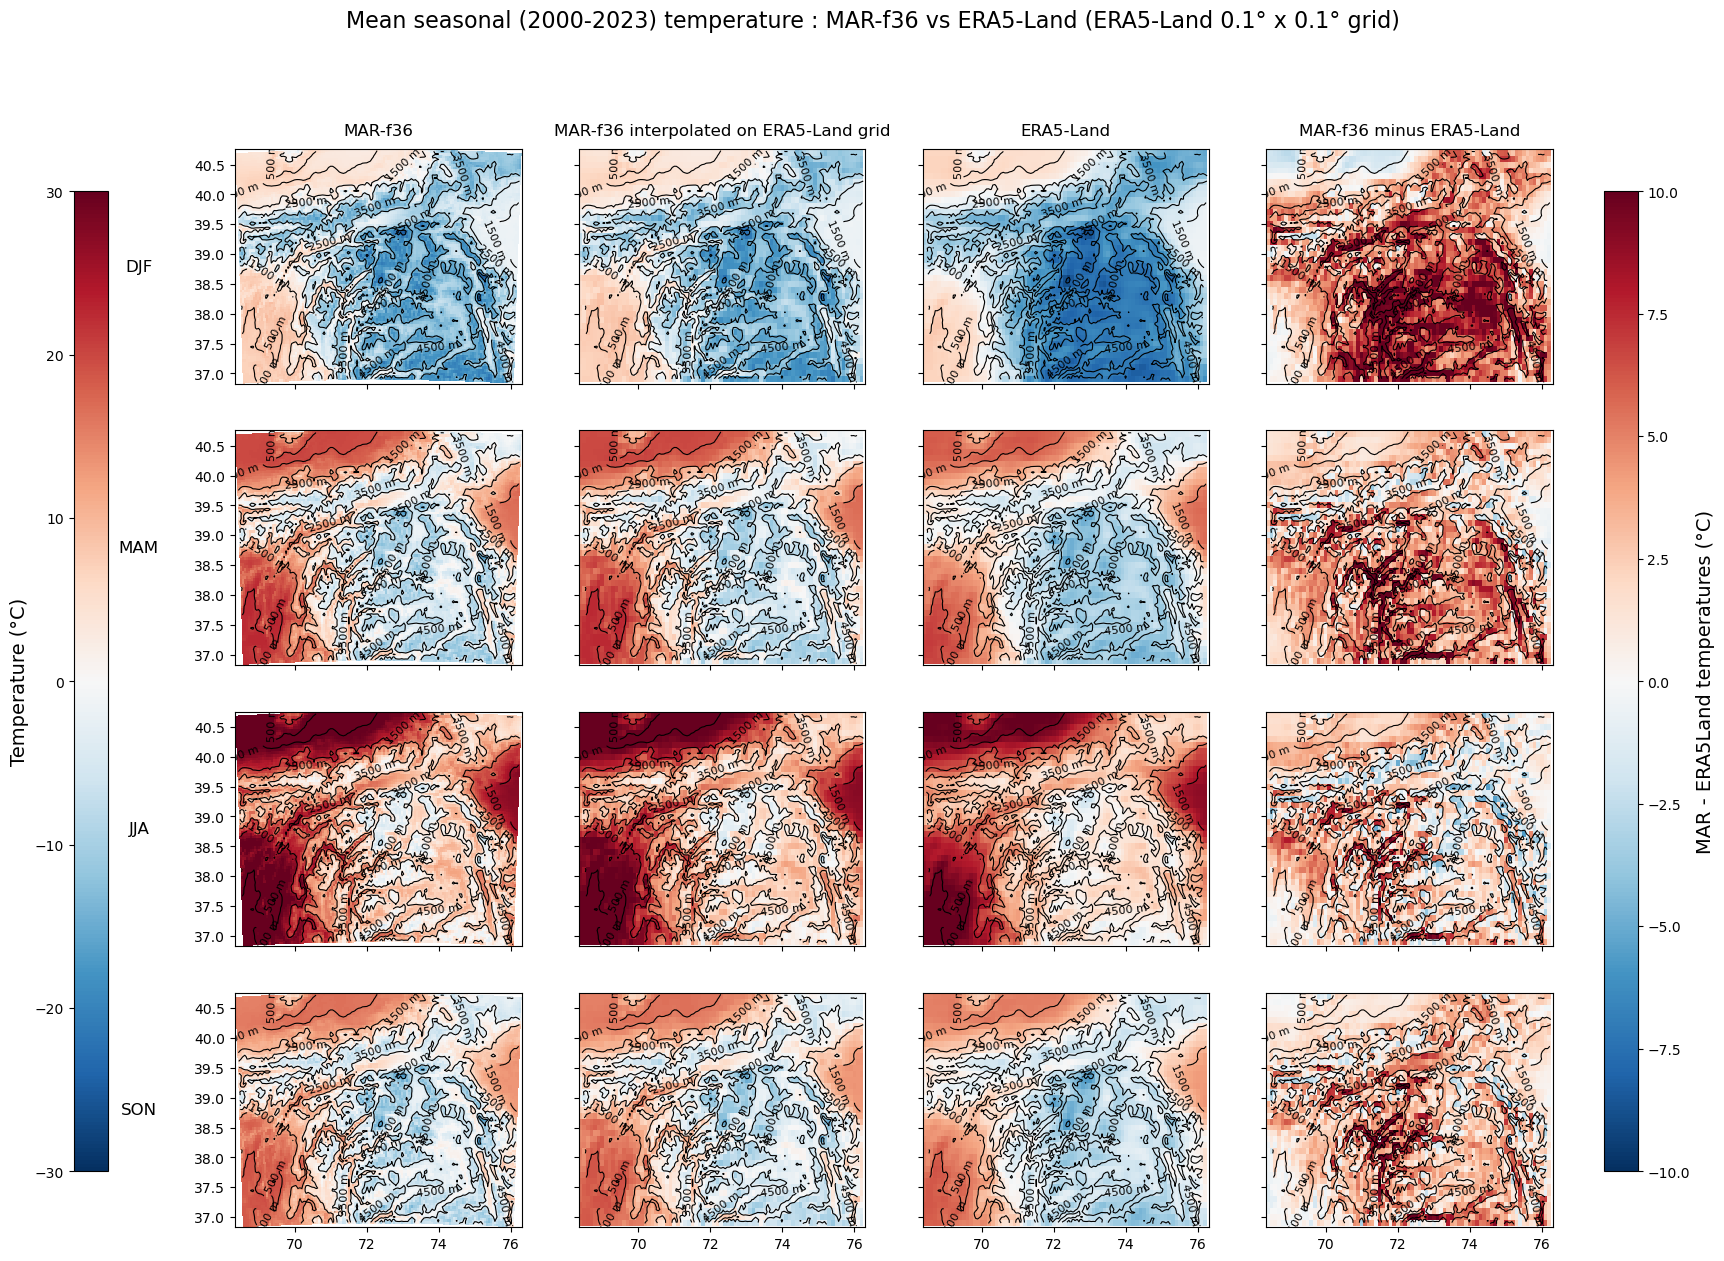

In [40]:
nrows = 4
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(17, 14)) 

j = k = l = q = 0
levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 

row_labels = season_list
col_labels = ['MAR-'+d+'36', 'MAR-'+d+'36 interpolated on ERA5-Land grid','ERA5-Land' ,'MAR-'+d+'36 minus ERA5-Land']

diff_meshes = []

# Paramètres communs aux colonnes 1 et 3
temp_cmap = 'RdBu_r'
temp_vmin = -30
temp_vmax = 30

for i, ax in enumerate(axes.flat):
    if (i) % 4 == 0 : 
        m = ax.pcolormesh(dsF_lon, dsF_lat,
                          ds_TTZ_36.groupby("TIME.season").mean('TIME').sel(season=season_list[j]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        j += 1
    
    
    elif (i-1) % 4 == 0 : 
        m = ax.pcolormesh(ds_TTZ_36_era5land.lon, ds_TTZ_36_era5land.lat,
                          ds_TTZ_36_era5land.groupby("TIME.season").mean('TIME').sel(season=season_list[k]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        k += 1

    elif (i-2) % 4 == 0 : 
        m = ax.pcolormesh(ds_obs.lon, ds_obs.lat,
                          ds_obs.groupby("TIME.season").mean('TIME').sel(season=season_list[q]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        q += 1
    
    elif (i-3) % 4 == 0 : 
        diff = (ds_TTZ_36_era5land.groupby('TIME.season').mean('TIME').sel(season=season_list[l])
                - ds_obs.groupby("TIME.season").mean('TIME').sel(season=season_list[l]))
        m = ax.pcolormesh(ds_TTZ_36_era5land.lon, ds_TTZ_36_era5land.lat, diff, 
                          cmap='RdBu_r', shading='auto', vmin=-10, vmax=10)
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')
        l += 1
        diff_meshes.append(m)
    
fig.suptitle('Mean seasonal (2000-2023) temperature : MAR-'+d+'36 vs ERA5-Land (ERA5-Land 0.1° x 0.1° grid)', fontsize=16)

# Colorbar gauche
cbar_ax_left = fig.add_axes([0.03, 0.15, 0.02, 0.7])
sm_left = ScalarMappable(cmap=temp_cmap, norm=plt.Normalize(vmin=temp_vmin, vmax=temp_vmax))
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='vertical')
cbar_left.ax.set_ylabel('Temperature (°C)', fontsize=14) 
cbar_left.ax.yaxis.set_ticks_position('left')
cbar_left.ax.yaxis.set_label_position('left')

# # Colorbar droite 
cbar_ax_right = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar_right = fig.colorbar(diff_meshes[0], cax=cbar_ax_right, orientation='vertical')
cbar_right.ax.set_ylabel('MAR - ERA5Land temperatures (°C)', fontsize=14) 

# Titres de colonnes
for ax, col in zip(axes[0], col_labels):
    ax.set_title(col, fontsize=12, pad=10)

# Labels de lignes (saisons)
for ax, row in zip(axes[:, 0], row_labels):
    ax.set_ylabel(row, fontsize=12, rotation=0, labelpad=40, va='center')

plt.savefig(folder_figure+'MAR'+d+'36_ERA5land_ERA5Landgrid_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()

## Seasonnal patterns: MAR-f37 vs ERA5-Land (interpolated on ERA5-Land grid)

In [41]:
#Rload MAR sensitivity dataset interpolated on OBS grid
ds_TTZ_37_era5land = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/fainx/mar/sensitivity_tests/'+'TTZ_daymean_MARv3.14_ER5_sensitivity_tests_'+domain+'_2016_remap_era5-land.'+d+'37.nc')['TTZ'].isel(ZTQLEV=0)

ds_TTZ_37_era5land = ds_TTZ_37_era5land.rename({'lon':'longitude','lat':'latitude'})
ds_TTZ_37_era5land = ds_TTZ_37_era5land.rename({'x':'lon','y':'lat'})

ds_TTZ_37_era5land = ds_TTZ_37_era5land.where((ds_TTZ_37_era5land.lat >= lat_min) & (ds_TTZ_37_era5land.lat <= lat_max), drop=True)
ds_TTZ_37_era5land = ds_TTZ_37_era5land.where((ds_TTZ_37_era5land.lon >= lon_min) & (ds_TTZ_37_era5land.lon <= lon_max), drop=True)

/tmp/ipykernel_1921226/2586092740.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_lon, dsF_lat,
/tmp/ipykernel_1921226/2586092740.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_lon, dsF_lat,
/tmp/ipykernel_1921226/2586092740.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_lon, dsF_lat,
/tmp/ipykerne

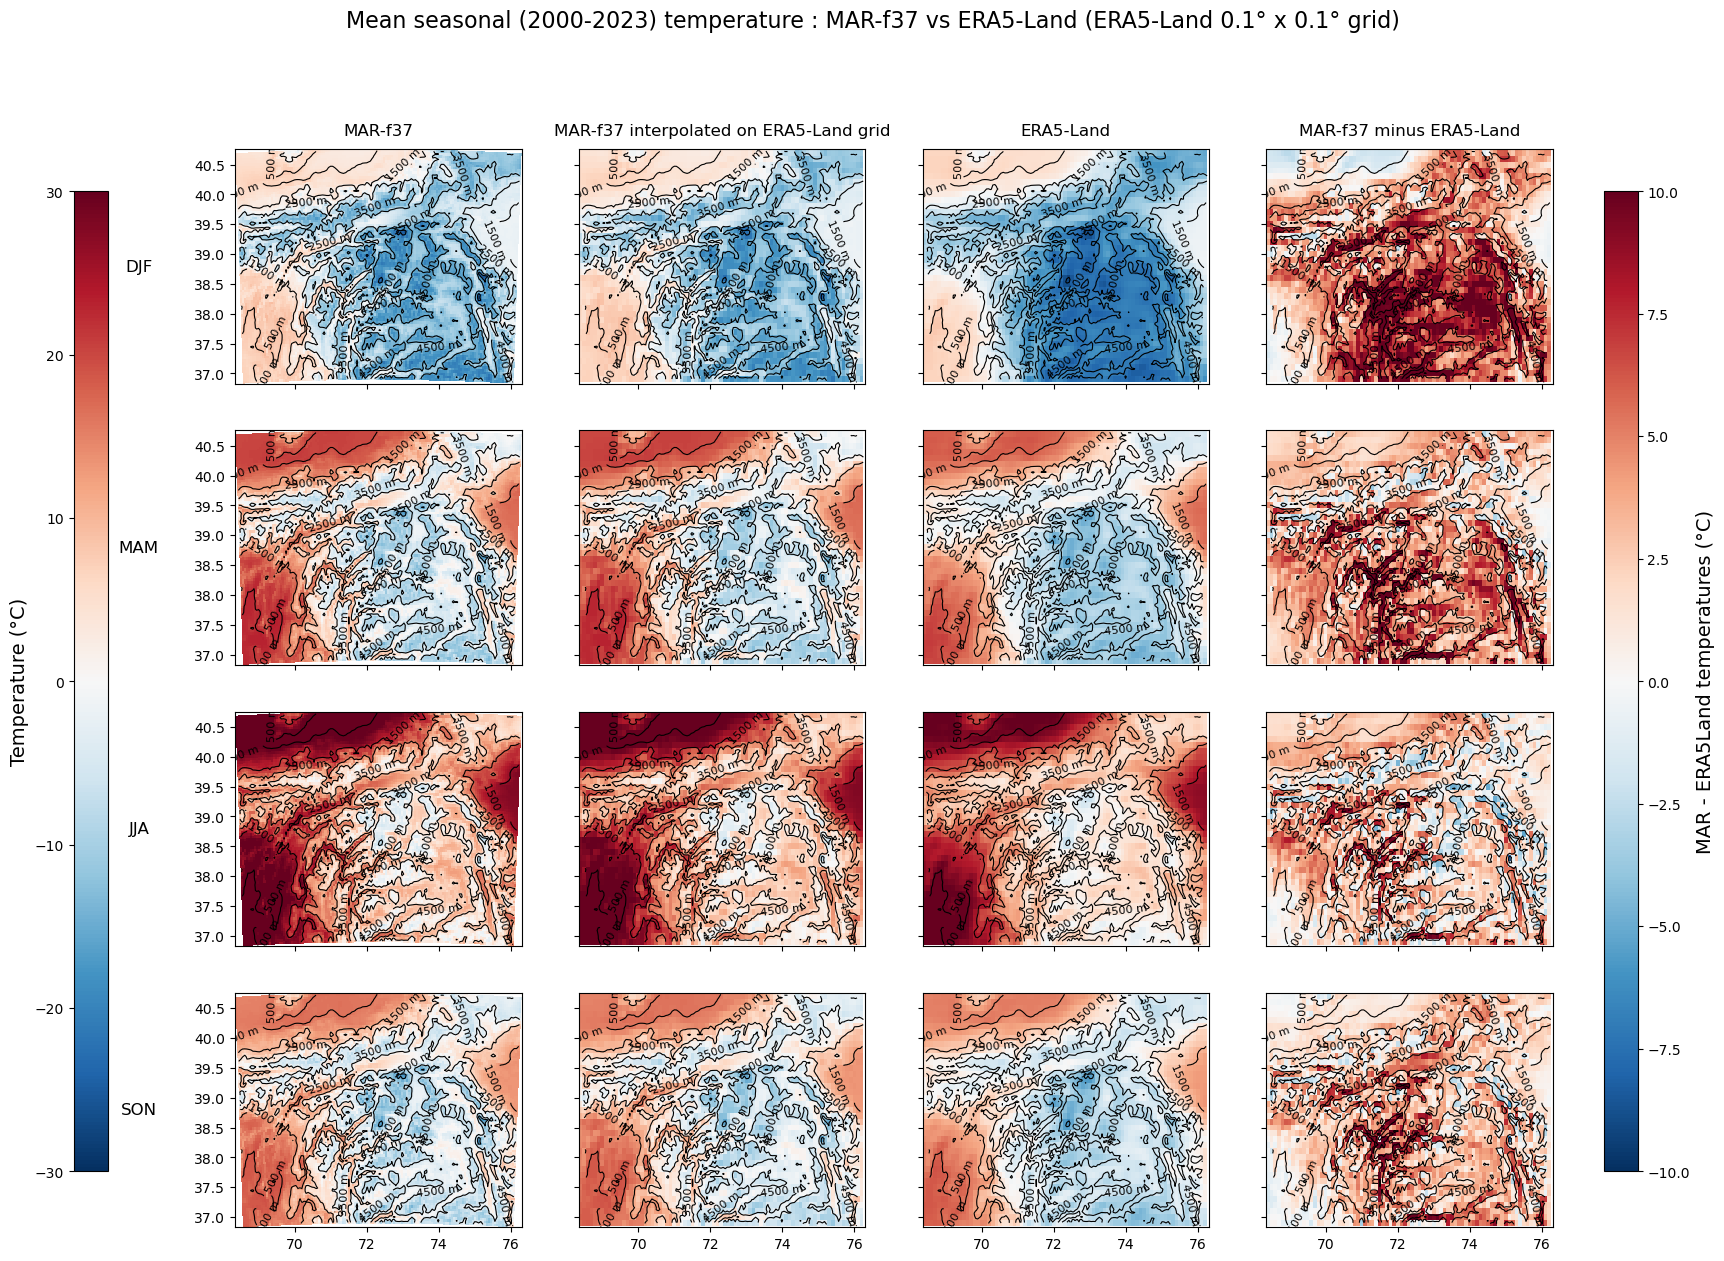

In [42]:
nrows = 4
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(17, 14)) 

j = k = l = q = 0
levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 

row_labels = season_list
col_labels = ['MAR-'+d+'37', 'MAR-'+d+'37 interpolated on ERA5-Land grid','ERA5-Land' ,'MAR-'+d+'37 minus ERA5-Land']

diff_meshes = []

# Paramètres communs aux colonnes 1 et 3
temp_cmap = 'RdBu_r'
temp_vmin = -30
temp_vmax = 30

for i, ax in enumerate(axes.flat):
    if (i) % 4 == 0 : 
        m = ax.pcolormesh(dsF_lon, dsF_lat,
                          ds_TTZ_37.groupby("TIME.season").mean('TIME').sel(season=season_list[j]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        j += 1
    
    
    elif (i-1) % 4 == 0 : 
        m = ax.pcolormesh(ds_TTZ_37_era5land.lon, ds_TTZ_37_era5land.lat,
                          ds_TTZ_37_era5land.groupby("TIME.season").mean('TIME').sel(season=season_list[k]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        k += 1

    elif (i-2) % 4 == 0 : 
        m = ax.pcolormesh(ds_obs.lon, ds_obs.lat,
                          ds_obs.groupby("TIME.season").mean('TIME').sel(season=season_list[q]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        q += 1
    
    elif (i-3) % 4 == 0 : 
        diff = (ds_TTZ_37_era5land.groupby('TIME.season').mean('TIME').sel(season=season_list[l])
                - ds_obs.groupby("TIME.season").mean('TIME').sel(season=season_list[l]))
        m = ax.pcolormesh(ds_TTZ_37_era5land.lon, ds_TTZ_37_era5land.lat, diff, 
                          cmap='RdBu_r', shading='auto', vmin=-10, vmax=10)
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')
        l += 1
        diff_meshes.append(m)
    
fig.suptitle('Mean seasonal (2000-2023) temperature : MAR-'+d+'37 vs ERA5-Land (ERA5-Land 0.1° x 0.1° grid)', fontsize=16)

# Colorbar gauche
cbar_ax_left = fig.add_axes([0.03, 0.15, 0.02, 0.7])
sm_left = ScalarMappable(cmap=temp_cmap, norm=plt.Normalize(vmin=temp_vmin, vmax=temp_vmax))
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='vertical')
cbar_left.ax.set_ylabel('Temperature (°C)', fontsize=14) 
cbar_left.ax.yaxis.set_ticks_position('left')
cbar_left.ax.yaxis.set_label_position('left')

# # Colorbar droite 
cbar_ax_right = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar_right = fig.colorbar(diff_meshes[0], cax=cbar_ax_right, orientation='vertical')
cbar_right.ax.set_ylabel('MAR - ERA5Land temperatures (°C)', fontsize=14) 

# Titres de colonnes
for ax, col in zip(axes[0], col_labels):
    ax.set_title(col, fontsize=12, pad=10)

# Labels de lignes (saisons)
for ax, row in zip(axes[:, 0], row_labels):
    ax.set_ylabel(row, fontsize=12, rotation=0, labelpad=40, va='center')

plt.savefig(folder_figure+'MAR'+d+'37_ERA5land_ERA5Landgrid_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()

## Altitudinal Profiles

#### All seasons

In [19]:
dsList=[ds_TTZ_30-ds_TTZ_s2, ds_TTZ_31-ds_TTZ_s2, ds_TTZ_32-ds_TTZ_s2, ds_TTZ_33-ds_TTZ_s2, ds_TTZ_34-ds_TTZ_s2, ds_TTZ_35-ds_TTZ_s2, ds_TTZ_36-ds_TTZ_s2, ds_TTZ_37-ds_TTZ_s2]

In [20]:
mean_tmp_by_elev_List=[]

for elem in dsList:
    tmp_flat = elem.mean('TIME').values.flatten()
    df = pd.DataFrame({'elevation': elev_flat, 'tmp': tmp_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
    mean_tmp_by_elev_List.append(mean_tmp_by_elev)    

/tmp/ipykernel_1921226/1135626708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_1921226/1135626708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_1921226/1135626708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean(

In [21]:
elev_bin_labels_R=np.array([0, 125.,  375.,  625.,  875., 1125., 1375., 1625., 1875., 2125.,
       2375., 2625., 2875., 3125., 3375., 3625., 3875., 4125., 4375.,
       4625., 4875., 5125., 5375., 5625., 5875., 6125., 6375., 6625.,
       6875., 7125.])

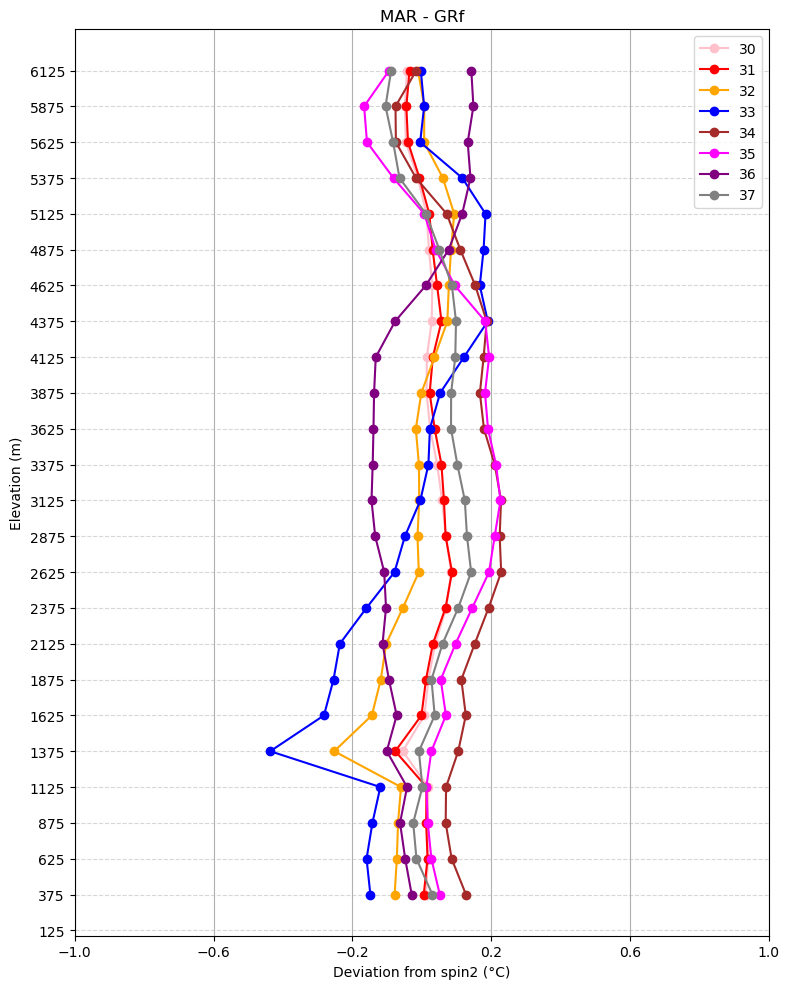

In [31]:
fig=plt.figure(figsize=(8, 10))

# plt.plot(mean_tmp_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan',
#          label=modelList[2+0])

for i in np.arange(0,len(dsList[1:])+1,1):
                   
    plt.plot(mean_tmp_by_elev_List[i].values,elev_bin_labels, marker='o',color=colorList[i-1],
         label=modelList[2+i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.xlim([-1, 1])  
plt.xticks(np.arange(-1, 1.4, 0.4))
plt.ylabel('Elevation (m)')
plt.xlabel('Deviation from spin2 (°C)')
plt.title('MAR - ' + domain)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(folder_figure+'MAR_altitudinal_deviation_from_spin2_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()

#### Seasonnality

In [24]:
dsList_per=[ds_TTZ_30_per-ds_TTZ_s2_per, ds_TTZ_31_per-ds_TTZ_s2_per, ds_TTZ_32_per-ds_TTZ_s2_per, ds_TTZ_33_per-ds_TTZ_s2_per, ds_TTZ_34_per-ds_TTZ_s2_per, ds_TTZ_35_per-ds_TTZ_s2_per, ds_TTZ_36_per-ds_TTZ_s2_per, ds_TTZ_37_per-ds_TTZ_s2_per]

/tmp/ipykernel_1921226/258862546.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_1921226/258862546.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_1921226/258862546.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/

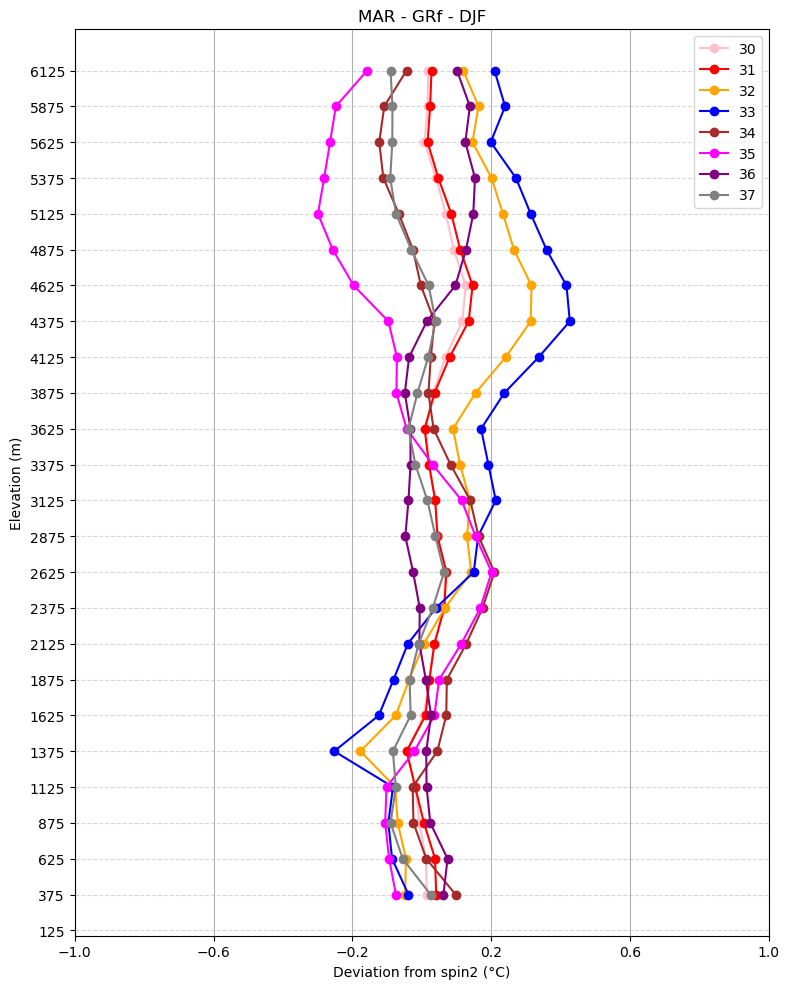

In [29]:
season = 'DJF'
mean_tmp_by_elev_List_DJF=[]

for elem in dsList_per:
    tmp_flat = elem.sel(season = season).values.flatten()
    df = pd.DataFrame({'elevation': elev_flat, 'tmp': tmp_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
    mean_tmp_by_elev_List_DJF.append(mean_tmp_by_elev)    

fig=plt.figure(figsize=(8, 10))

# plt.plot(mean_tmp_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan',
#          label=modelList[2+0])

for i in np.arange(0,len(dsList_per[1:])+1,1):
                   
    plt.plot(mean_tmp_by_elev_List_DJF[i].values,elev_bin_labels, marker='o',color=colorList[i-1],
         label=modelList[2+i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.xlim([-1, 1])  
plt.xticks(np.arange(-1, 1.4, 0.4))
plt.ylabel('Elevation (m)')
plt.xlabel('Deviation from spin2 (°C)')
plt.title('MAR - ' + domain + ' - ' + season)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(folder_figure+'MAR_altitudinal_deviation_from_spin2_'+ season +'_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1921226/2362106895.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_1921226/2362106895.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_1921226/2362106895.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean(

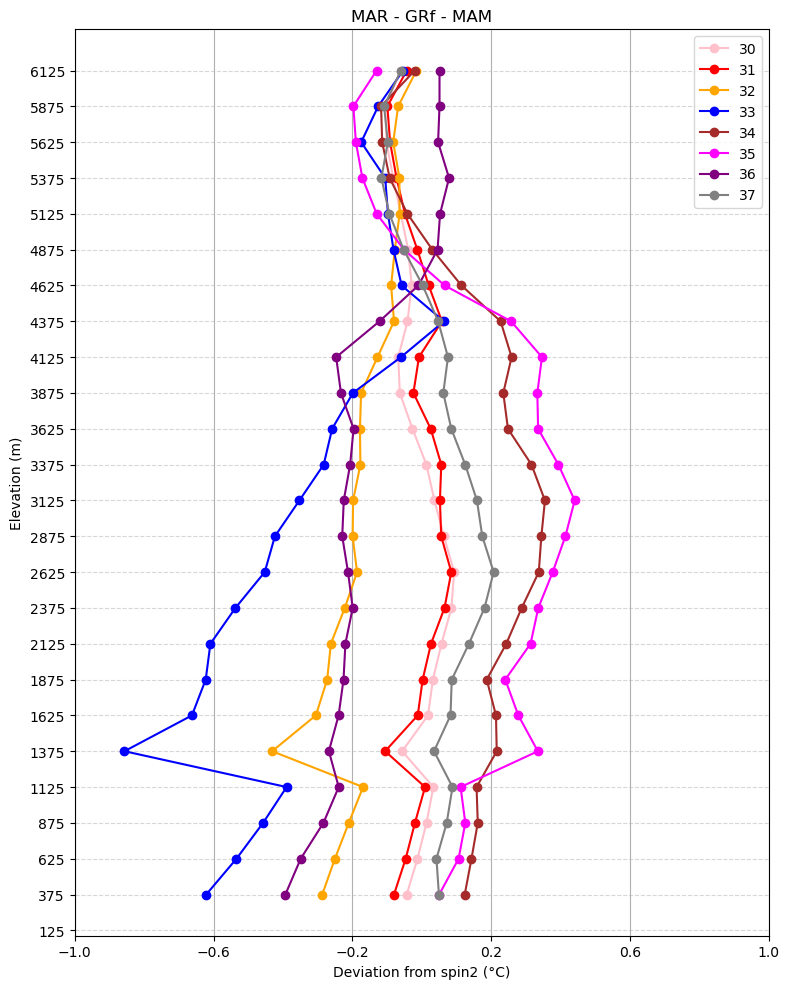

In [30]:
season = 'MAM'
mean_tmp_by_elev_List_DJF=[]

for elem in dsList_per:
    tmp_flat = elem.sel(season = season).values.flatten()
    df = pd.DataFrame({'elevation': elev_flat, 'tmp': tmp_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
    mean_tmp_by_elev_List_DJF.append(mean_tmp_by_elev)   

fig=plt.figure(figsize=(8, 10))

# plt.plot(mean_tmp_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan',
#          label=modelList[2+0])

for i in np.arange(0,len(dsList_per[1:])+1,1):
                   
    plt.plot(mean_tmp_by_elev_List_DJF[i].values,elev_bin_labels, marker='o',color=colorList[i-1],
         label=modelList[2+i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.xlim([-1, 1])  
plt.xticks(np.arange(-1, 1.4, 0.4))
plt.ylabel('Elevation (m)')
plt.xlabel('Deviation from spin2 (°C)')
plt.title('MAR - ' + domain + ' - ' + season)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(folder_figure+'MAR_altitudinal_deviation_from_spin2_'+ season +'_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1921226/2607289991.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_1921226/2607289991.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_1921226/2607289991.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean(

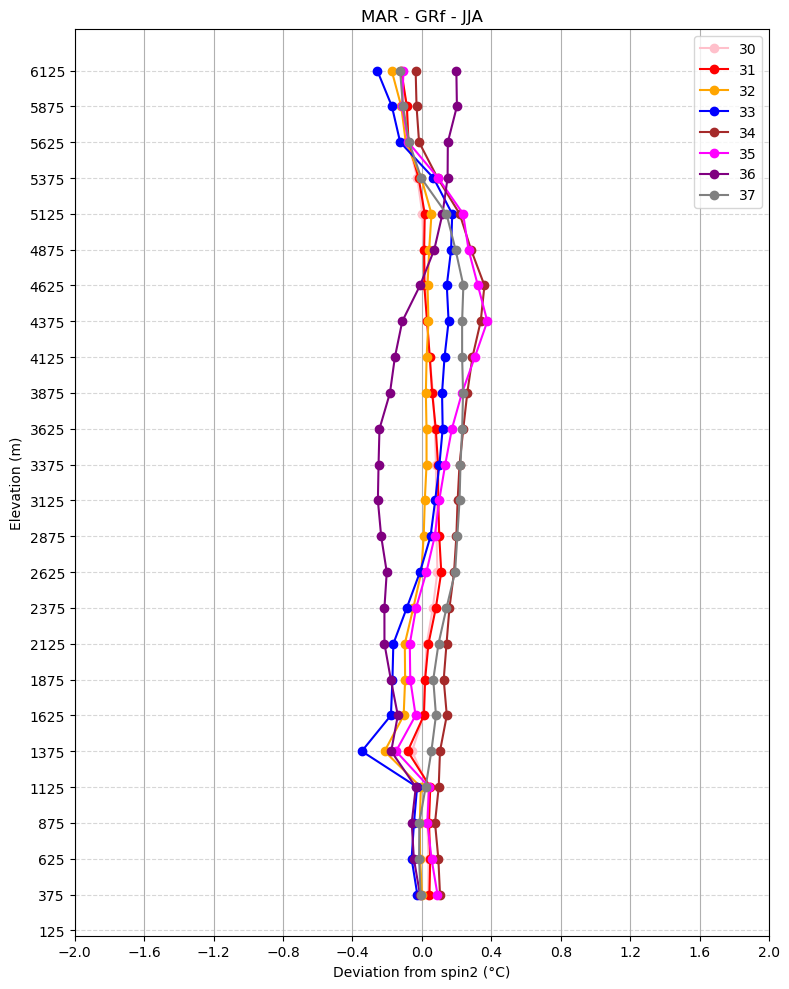

In [27]:
season = 'JJA'
mean_tmp_by_elev_List_DJF=[]

for elem in dsList_per:
    tmp_flat = elem.sel(season = season).values.flatten()
    df = pd.DataFrame({'elevation': elev_flat, 'tmp': tmp_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
    mean_tmp_by_elev_List_DJF.append(mean_tmp_by_elev) 

fig=plt.figure(figsize=(8, 10))

# plt.plot(mean_tmp_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan',
#          label=modelList[2+0])

for i in np.arange(0,len(dsList_per[1:])+1,1):
                   
    plt.plot(mean_tmp_by_elev_List_DJF[i].values,elev_bin_labels, marker='o',color=colorList[i-1],
         label=modelList[2+i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.xlim([-2, 2])  
plt.xticks(np.arange(-2, 2.4, 0.4))
plt.ylabel('Elevation (m)')
plt.xlabel('Deviation from spin2 (°C)')
plt.title('MAR - ' + domain + ' - ' + season)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(folder_figure+'MAR_altitudinal_deviation_from_spin2_'+ season +'_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1921226/2607562344.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_1921226/2607562344.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
/tmp/ipykernel_1921226/2607562344.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean(

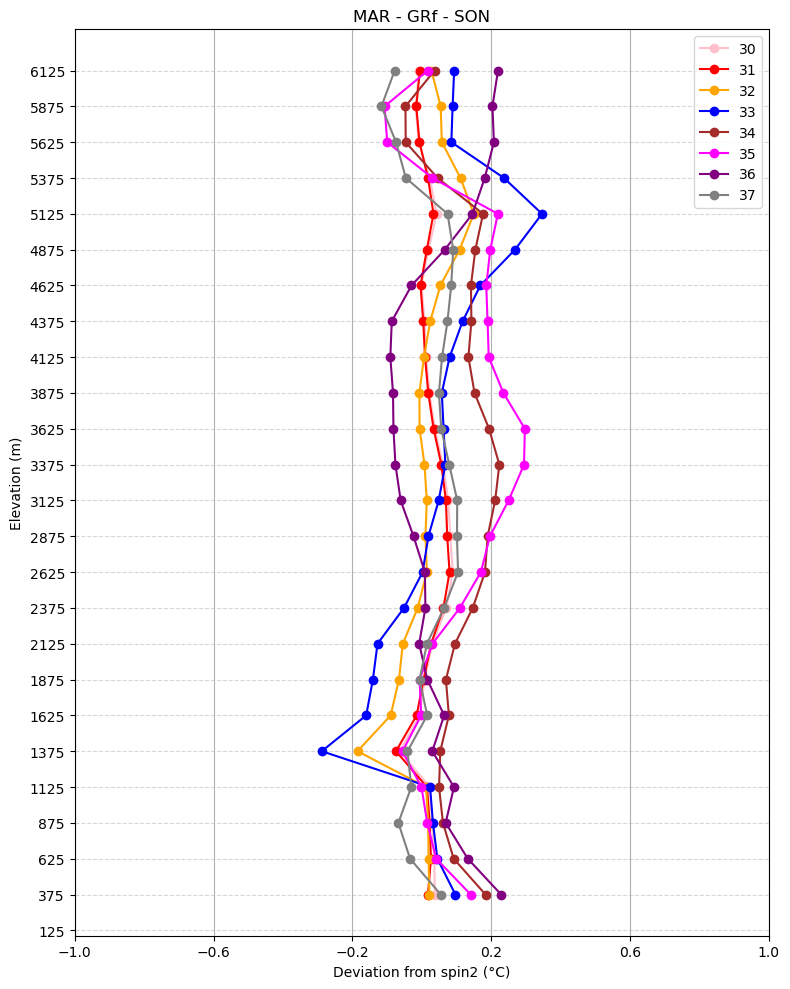

In [32]:
season = 'SON'
mean_tmp_by_elev_List_DJF=[]

for elem in dsList_per:
    tmp_flat = elem.sel(season = season).values.flatten()
    df = pd.DataFrame({'elevation': elev_flat, 'tmp': tmp_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
    mean_tmp_by_elev_List_DJF.append(mean_tmp_by_elev)  

fig=plt.figure(figsize=(8, 10))

# plt.plot(mean_tmp_by_elev_List[0].values,elev_bin_labels, marker='o',color='cyan',
#          label=modelList[2+0])

for i in np.arange(0,len(dsList_per[1:])+1,1):
                   
    plt.plot(mean_tmp_by_elev_List_DJF[i].values,elev_bin_labels, marker='o',color=colorList[i-1],
         label=modelList[2+i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.xlim([-1, 1])  
plt.xticks(np.arange(-1, 1.4, 0.4))
plt.ylabel('Elevation (m)')
plt.xlabel('Deviation from spin2 (°C)')
plt.title('MAR - ' + domain + ' - ' + season)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(folder_figure+'MAR_altitudinal_deviation_from_spin2_'+ season +'_'+ domain+'.png',format='png', bbox_inches='tight')
plt.show()